# Environment

In [1]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../01_Functions_classes_and_variables").resolve()
sys.path.append(str(module_path))

from simulation_data_functions import *
from data_exploration_functions import *

import matplotlib.pyplot as plt
from spreg import ML_Lag
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

from esda.moran import Moran

# Simulating data

## Single df

### Creating

In [18]:
gdf_output = return_spatial_geo_df(n_x = 40,  
    n_y = 20,    
    spacing = 100, 
    treated_scope_x_start = 10,
    treated_scope_x_end = 24,
    treated_scope_y_start = 7,
    treated_scope_y_end = 13,
    ATT_target = 1.5,
    y_spatial_autocorelation_scope_x_start = 3,
    y_spatial_autocorelation_scope_x_end = 25,
    y_spatial_autocorelation_scope_y_start = 4,
    y_spatial_autocorelation_scope_y_end = 11,
    rho = 0.15,
    spatial_confounder_scope_x_start = 12,
    spatial_confounder_scope_x_end = 32,
    spatial_confounder_scope_y_start = 2,
    spatial_confounder_scope_y_end = 18,
    lambda_cs = 0.2,
    distance_ring_number = 2,
    distance_ring_ate_scalars=[0.4, 0.15],
    nonspatial_confounders_contribution_to_Y=1.0,
    spatial_confounder_contribution_to_Y=0.7,
    epsilon_distribution_mean = 0.025,
    epsilon_distribution_standard_error = 0.2)

#### Numerical checks

In [19]:
gdf_output

,unit_id,geometry,x,y,T,propensity,C1,C2,C3,Cs,tau,spill,Y,Y_ns
0,1000,POINT (0 0),0,0,0,0.076162,-1.925909,0.348347,0.414708,0.965388,0.0,0.0,0.101338,0.101338
1,1001,POINT (0 100),0,100,0,1.416383,1.282540,-0.934311,0.580946,0.372307,0.0,0.0,0.973599,0.973599
2,1002,POINT (0 200),0,200,0,0.999673,-0.571097,-0.582296,1.781744,0.496573,0.0,0.0,0.509437,0.509437
3,1003,POINT (0 300),0,300,0,0.286370,-1.894880,0.972316,-1.825290,1.989711,0.0,0.0,0.280741,0.280741
4,1004,POINT (0 400),0,400,0,-1.386017,-1.468889,-0.197362,-1.888115,0.954201,0.0,0.0,-0.804596,-0.804596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,1795,POINT (3900 1500),3900,1500,0,-0.733806,-0.298186,0.754496,-0.710110,-1.153499,0.0,0.0,-0.877546,-0.877546
796,1796,POINT (3900 1600),3900,1600,0,-1.434305,-0.126785,1.570615,-1.193156,-1.726640,0.0,0.0,-0.644537,-0.644537
797,1797,POINT (3900 1700),3900,1700,0,-0.678173,-0.654429,-0.805287,-0.212066,0.023409,0.0,0.0,-0.591250,-0.591250
798,1798,POINT (3900 1800),3900,1800,0,-1.971648,-0.273903,-1.005200,-0.085339,-0.794091,0.0,0.0,-1.068921,-1.068921


In [20]:
gdf_output[gdf_output['T']==1]['tau'].mean()

np.float64(1.5000000000000002)

In [21]:
gdf_output.isna().any().any()

np.False_

In [22]:
gdf_output[gdf_output['spill']!=0]

,unit_id,geometry,x,y,T,propensity,C1,C2,C3,Cs,tau,spill,Y,Y_ns
167,1167,POINT (800 700),800,700,0,0.826810,-0.448001,0.748042,0.222422,0.735546,0.0,0.077148,0.843424,0.969579
168,1168,POINT (800 800),800,800,0,-3.129857,0.146879,-1.822612,-1.097558,-0.967885,0.0,0.153016,-2.055880,-2.144977
169,1169,POINT (800 900),800,900,0,1.927946,1.682309,0.162966,-0.068747,1.169533,0.0,0.178936,2.236142,2.358211
170,1170,POINT (800 1000),800,1000,0,-1.810736,-1.218340,-0.858856,0.132844,-0.422634,0.0,0.330712,-1.412896,-1.535835
171,1171,POINT (800 1100),800,1100,0,0.724900,0.732797,0.137679,1.169333,-0.238138,0.0,0.259362,0.775114,0.926638
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
529,1529,POINT (2600 900),2600,900,0,-0.006229,-1.710315,-0.421076,0.549539,0.391739,0.0,0.257875,-0.049868,-0.049868
530,1530,POINT (2600 1000),2600,1000,0,-1.799400,-1.414440,0.397475,0.550951,-0.733287,0.0,0.172024,-0.191253,-0.191253
531,1531,POINT (2600 1100),2600,1100,0,-0.796842,-0.440502,-0.001967,-0.786197,0.048829,0.0,0.276327,0.044077,0.044077
532,1532,POINT (2600 1200),2600,1200,0,-0.758600,0.300055,-0.694561,-0.242046,0.131533,0.0,0.234708,0.398544,0.398544


In [23]:
coords = np.array(list(zip(gdf_output["x"], gdf_output["y"])))

W = DistanceBand(coords, threshold=101, binary=True, silence_warnings=True)
W.transform = "R" 
moran_I_y= Moran(gdf_output['Y'], W)
[f'Moran I: {moran_I_y.I:.4f}',  f'p-value simulated: {moran_I_y.p_sim:.4f}']

['Moran I: 0.1866', 'p-value simulated: 0.0010']

#### Visual checks

<Axes: >

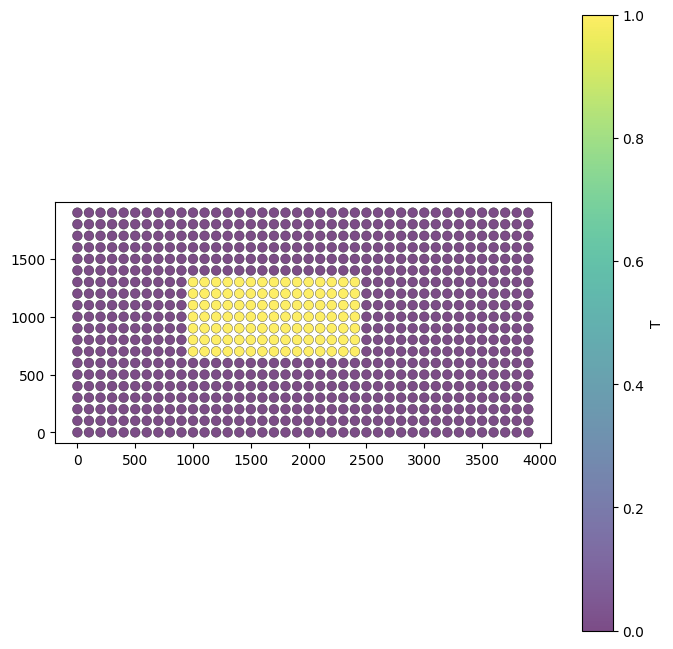

In [24]:
plot_gdf_points(gdf_output, #size_col='Y',
    color_col='T')

<Axes: >

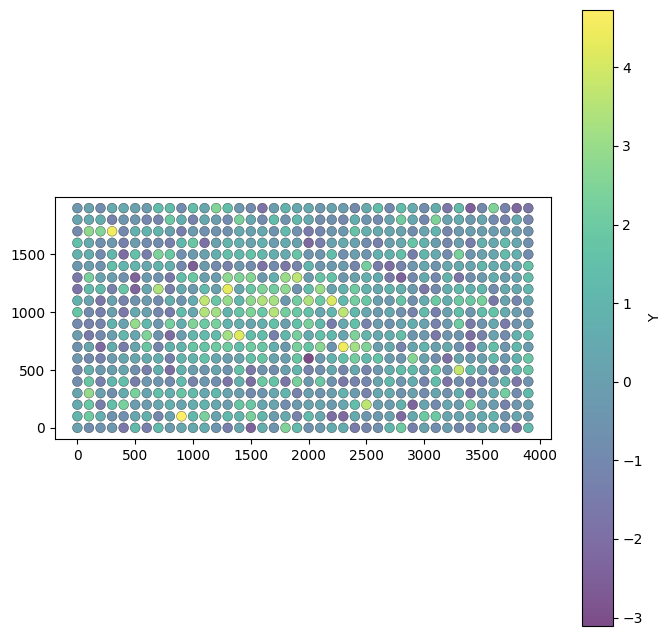

In [25]:
plot_gdf_points(gdf_output, #size_col='Y',
    color_col='Y')

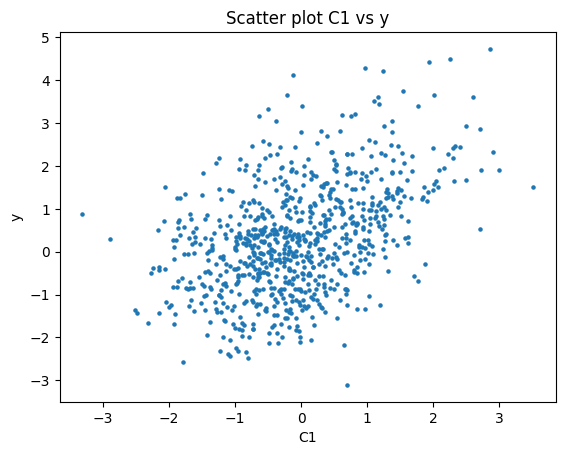

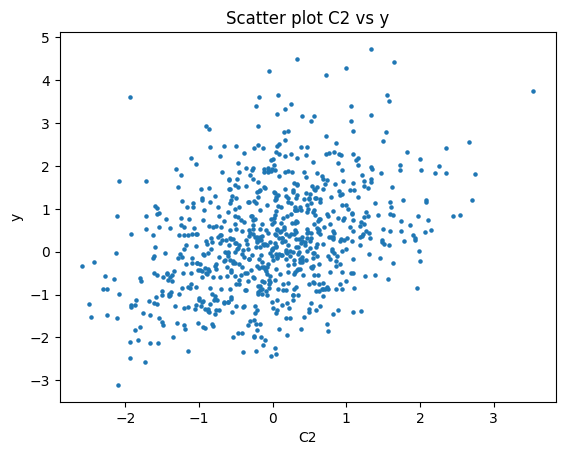

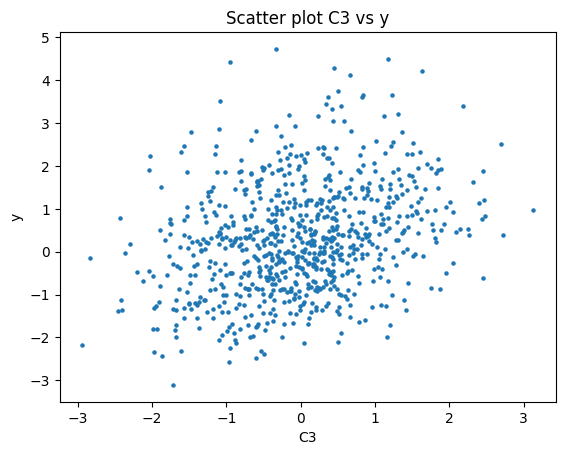

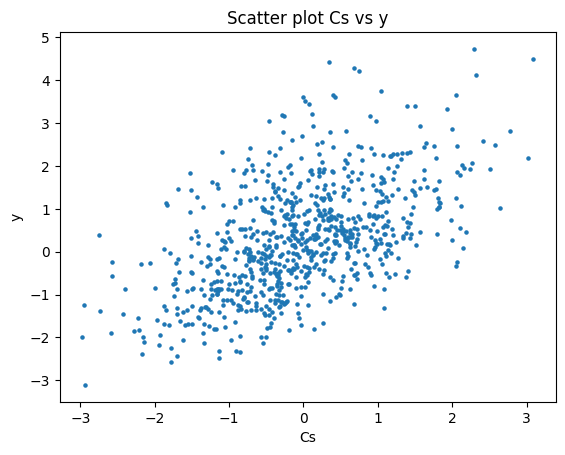

In [26]:
for i in ['C1','C2','C3','Cs']:
    gdf_output.plot.scatter(x=i, y="Y", s=5)
    plt.xlabel(i)
    plt.ylabel("y")
    plt.title(f"Scatter plot {i} vs y")
    plt.show()

#### Modelling checks

##### Data

In [27]:
X1 = gdf_output[["C1","C2",
         #"C3","Cs",
         'T'
         ]].values
X = gdf_output[["C1","C2",
         #"C3","Cs"
         ]].values
y = gdf_output["Y"].values.reshape(-1,1)
T = gdf_output["T"].values
Xdf = gdf_output[["C1","C2",'T',
         #"C3","Cs"
         ]]
X_l = sm.add_constant(Xdf)
y_l = gdf_output["Y_ns"]
Y = gdf_output['Y'].values

X_logit = sm.add_constant(X)

##### Logit for T

In [28]:
logit_model = sm.Logit(T, X_logit)
logit_res = logit_model.fit()

print(logit_res.summary())

Optimization terminated successfully.
         Current function value: 0.387543
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  800
Model:                          Logit   Df Residuals:                      797
Method:                           MLE   Df Model:                            2
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                0.003121
Time:                        18:43:05   Log-Likelihood:                -310.03
converged:                       True   LL-Null:                       -311.00
Covariance Type:            nonrobust   LLR p-value:                    0.3788
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.9017      0.106    -17.926      0.000      -2.110      -1.694
x1            -0.0851      0.

##### Cross sectional linear difference in differences 

In [29]:
model = sm.OLS(y_l, X_l)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   Y_ns   R-squared:                       0.499
Model:                            OLS   Adj. R-squared:                  0.497
Method:                 Least Squares   F-statistic:                     264.6
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          4.24e-119
Time:                        18:43:10   Log-Likelihood:                -1031.4
No. Observations:                 800   AIC:                             2071.
Df Residuals:                     796   BIC:                             2090.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1549      0.033      4.625      0.0

##### Cross sectional difference in differences with spatial lag of Y

In [30]:
model_sdm = ML_Lag(
    y,
    X1,
    w=W,              
    slx_lags=1,       
    name_y="Y",
    name_x=["C1","C2", 'T'#,"C3","Cs"
            ]
)

print(model_sdm.summary)

ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG WITH SLX - SPATIAL DURBIN MODEL (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :           Y                Number of Observations:         800
Mean dependent var  :      0.3011                Number of Variables   :           8
S.D. dependent var  :      1.2668                Degrees of Freedom    :         792
Pseudo R-squared    :      0.5229
Spatial Pseudo R-squared:  0.5190
Log likelihood      :  -1028.9430
Sigma-square ML     :      0.7647                Akaike info criterion :    2073.886
S.E of regression   :      0.8745                Schwarz criterion     :    2111.363

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----

##### Basic causal forest

In [31]:
forest_Y = RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42)
forest_Y.fit(X, Y)

forest_T = RandomForestRegressor(n_estimators=180, max_depth=10, random_state=42)
forest_T.fit(X, T)

cf = CausalForestDML(model_y=forest_Y, model_t=forest_T, random_state=42)
cf.fit(Y, T, X=X)
tau_hat = cf.effect(X)



ate = tau_hat.mean()
se_ate = tau_hat.std(ddof=1) / np.sqrt(len(tau_hat))

ci_low_ate, ci_high_ate = ate - 1.96 * se_ate, ate + 1.96 * se_ate
gdf_rf_compare = gdf_output[['unit_id',	'geometry',	'T', 'tau']].copy()
gdf_rf_compare['tau_cf'] = tau_hat
gdf_rf_compare[gdf_rf_compare['T']==1]

,unit_id,geometry,T,tau,tau_cf
207,1207,POINT (1000 700),1,1.320232,1.042869
208,1208,POINT (1000 800),1,0.998000,1.165261
209,1209,POINT (1000 900),1,1.488572,1.671464
210,1210,POINT (1000 1000),1,1.654930,1.326315
211,1211,POINT (1000 1100),1,1.284284,1.116658
...,...,...,...,...,...
489,1489,POINT (2400 900),1,1.365022,1.655052
490,1490,POINT (2400 1000),1,1.415408,1.405190
491,1491,POINT (2400 1100),1,0.879883,1.063789
492,1492,POINT (2400 1200),1,1.689087,1.270991


In [32]:
ci_low_ate, ate, ci_high_ate

(np.float64(1.5094422227938422),
 np.float64(1.541708129138148),
 np.float64(1.5739740354824538))

In [33]:
gdf_rf_compare[gdf_rf_compare['T']==1]['tau_cf'].mean()

np.float64(1.5498267193278683)

## Generating multiple df for simulations

### Data generation

In [65]:
list_of_rhos = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55]
dict_of_output_gdf = {}
for i in list_of_rhos:
    single_gdf_output = return_spatial_geo_df(n_x = 40,  
        n_y = 20,    
        spacing = 100, 
        treated_scope_x_start = 10,
        treated_scope_x_end = 24,
        treated_scope_y_start = 7,
        treated_scope_y_end = 13,
        ATT_target = 1.5,
        y_spatial_autocorelation_scope_x_start = 3,
        y_spatial_autocorelation_scope_x_end = 25,
        y_spatial_autocorelation_scope_y_start = 4,
        y_spatial_autocorelation_scope_y_end = 11,
        rho = i,
        spatial_confounder_scope_x_start = 12,
        spatial_confounder_scope_x_end = 32,
        spatial_confounder_scope_y_start = 2,
        spatial_confounder_scope_y_end = 18,
        lambda_cs = 0.2,
        distance_ring_number = 2,
        distance_ring_ate_scalars=[0.4, 0.15],
        nonspatial_confounders_contribution_to_Y=1.0,
        spatial_confounder_contribution_to_Y=0.7,
        epsilon_distribution_mean = 0.025,
        epsilon_distribution_standard_error = 0.2)
    single_gdf_output2 = single_gdf_output.drop(columns = ['y', 'x']).copy()
    dict_of_output_gdf[f'gdf_rho_0_{str(i)[2:]}'] = single_gdf_output2

In [66]:
dict_of_output_gdf.keys()

dict_keys(['gdf_rho_0_1', 'gdf_rho_0_15', 'gdf_rho_0_2', 'gdf_rho_0_25', 'gdf_rho_0_3', 'gdf_rho_0_35', 'gdf_rho_0_4', 'gdf_rho_0_45', 'gdf_rho_0_5', 'gdf_rho_0_55'])

In [67]:
moran_I_y= Moran(dict_of_output_gdf['gdf_rho_0_55']['Y'], W)
[f'Moran I: {moran_I_y.I:.4f}',  f'p-value simulated: {moran_I_y.p_sim:.4f}']

['Moran I: 0.4247', 'p-value simulated: 0.0010']

### Data saving

In [54]:
repo_path_wndws = Path("../").resolve()
repo_path_unix = repo_path_wndws.as_posix() 
repo_path_r_string = repo_path_unix.replace("/", '\\')

In [ ]:
conn = sqlite3.connect(repo_path_r_string + r'\03_simulated_data\simulated_data.sqlite')
cursor = conn.cursor()

In [55]:
repo_path_r_string

'C:\\Users\\andre\\Desktop\\IDS\\02_VS_code\\03_comparing_causal_ML_models_with_spatial_effects'

In [68]:
for k in dict_of_output_gdf.keys():
    dict_of_output_gdf[k].to_file(
        repo_path_r_string + r'\03_simulated_data\simulated_data.sqlite',
        layer=k,
        driver="SQLite",
        #spatialite=True,
        #if_exists="replace"
    )